# POC SOC Triage — 03 Modèles ML

**Objectif** : entraîner deux modèles complémentaires :
- **Isolation Forest** (non-supervisé) : détecte les incidents anormaux sans labels → simule le démarrage à froid
- **XGBoost** (supervisé) : classifie TP/BP/FP avec les labels GUIDE → production

**Output** : `predictions_sample.csv` — 500 incidents prédits pour la démo Streamlit


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score,
                              precision_recall_curve, fbeta_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

DATA_DIR  = Path('data')
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Librairies OK')
print(f'XGBoost version: {xgb.__version__}')

Librairies OK
XGBoost version: 2.1.1


## 1. Chargement et split train/test

In [2]:
# Chargement depuis le parquet (dtypes int8 préservés, plus rapide que CSV)
df = pd.read_parquet(DATA_DIR / 'features_ml.parquet')

# OrgId est déjà dans features_ml 
FEATURE_COLS = [c for c in df.columns if c not in ['IncidentId', 'target', 'OrgId']]
X      = df[FEATURE_COLS].values
y      = df['target'].values
groups = df['OrgId'].values

print(f'Dataset : {len(df):,} incidents × {len(FEATURE_COLS)} features')
print(f'Distribution cible : {dict(pd.Series(y).value_counts().rename({0:"FP", 1:"BP", 2:"TP"}))}')
print(f'Nb organisations uniques : {df["OrgId"].nunique():,}')

Dataset : 30,000 incidents × 55 features
Distribution cible : {'BP': 14801, 'FP': 8399, 'TP': 6800}
Nb organisations uniques : 3,678


In [3]:
# --- Option A : chargement des encodeurs appris en 02_feature_engineering
# Ces tables permettront d'encoder les nouvelles alertes SIEM sans recalculer
# sur les données de test (évite le leakage)

encoder_alert_title = pd.read_parquet(DATA_DIR / 'encoder_alert_title.parquet')
encoder_category    = pd.read_parquet(DATA_DIR / 'encoder_category.parquet')
encoder_detector    = pd.read_parquet(DATA_DIR / 'encoder_detector.parquet')
encoder_org         = pd.read_parquet(DATA_DIR / 'encoder_org.parquet')

with open(DATA_DIR / 'global_rates.pkl', 'rb') as f:
    global_rates = pickle.load(f)

print('Encodeurs chargés :')
print(f'  alert_title : {len(encoder_alert_title):,} titres')
print(f'  category    : {len(encoder_category):,} catégories')
print(f'  detector    : {len(encoder_detector):,} détecteurs')
print(f'  org         : {len(encoder_org):,} organisations')
print(f'  global_rates: TP={global_rates["global_tp_rate"]:.3f} | '
      f'FP={global_rates["global_fp_rate"]:.3f} | '
      f'BP={global_rates["global_bp_rate"]:.3f}')

# Fonction d'encodage réutilisable pour l'inférence sur nouvelles alertes SIEM
def encode_new_alerts(df_new):
    """
    Applique les encodeurs appris sur le train set à un nouveau DataFrame d'alertes.
    df_new doit contenir : top_alert_title, top_category, top_detector, OrgId
    Retourne df_new enrichi des colonnes de target encoding.
    """
    df_enc = df_new.copy()

    # Alert title
    df_enc = df_enc.merge(encoder_alert_title, left_on='top_alert_title',
                          right_index=True, how='left')
    # Category
    df_enc = df_enc.merge(encoder_category, left_on='top_category',
                          right_index=True, how='left')
    # Detector
    df_enc = df_enc.merge(encoder_detector, left_on='top_detector',
                          right_index=True, how='left')
    # Org
    df_enc = df_enc.merge(encoder_org, left_on='OrgId',
                          right_index=True, how='left')

    # Fallback : nouvelles valeurs inconnues → taux globaux
    for col, val in [
        ('alert_title_tp_rate', global_rates['global_tp_rate']),
        ('alert_title_fp_rate', global_rates['global_fp_rate']),
        ('alert_title_bp_rate', global_rates['global_bp_rate']),
        ('category_tp_rate',    global_rates['global_tp_rate']),
        ('category_fp_rate',    global_rates['global_fp_rate']),
        ('category_bp_rate',    global_rates['global_bp_rate']),
        ('detector_tp_rate',    global_rates['global_tp_rate']),
        ('detector_fp_rate',    global_rates['global_fp_rate']),
        ('detector_bp_rate',    global_rates['global_bp_rate']),
        ('org_tp_rate',         global_rates['global_tp_rate']),
        ('org_fp_rate',         global_rates['global_fp_rate']),
        ('org_bp_rate',         global_rates['global_bp_rate']),
    ]:
        if col in df_enc.columns:
            df_enc[col] = df_enc[col].fillna(val)

    return df_enc

print('\nFonction encode_new_alerts() prête pour l\'inférence SIEM ✓')

Encodeurs chargés :
  alert_title : 4,760 titres
  category    : 18 catégories
  detector    : 223 détecteurs
  org         : 746 organisations
  global_rates: TP=0.227 | FP=0.279 | BP=0.493

Fonction encode_new_alerts() prête pour l'inférence SIEM ✓


In [4]:
# Split stratifié par OrgId : aucune org ne doit être dans train ET test
# → évite le leakage organisationnel
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
# On prend le premier fold : 80% train, 20% test
train_idx, test_idx = next(sgkf.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Train : {len(X_train):,} incidents')
print(f'Test  : {len(X_test):,} incidents')
print(f'Train distribution : {dict(pd.Series(y_train).value_counts().rename({0:"FP",1:"BP",2:"TP"}))}')
print(f'Test  distribution : {dict(pd.Series(y_test).value_counts().rename({0:"FP",1:"BP",2:"TP"}))}')

Train : 21,892 incidents
Test  : 8,108 incidents
Train distribution : {'BP': 10048, 'FP': 6816, 'TP': 5028}
Test  distribution : {'BP': 4753, 'TP': 1772, 'FP': 1583}


## 2. Modèle 1 — Isolation Forest (non-supervisé)

**Principe** : entraîné *sans labels* sur les incidents du train set. Il attribue un score d'anomalie à chaque incident. Les incidents les plus anormaux sont prioritaires pour l'analyste.

**Interprétation bancaire** : "Au démarrage, avant d'avoir des labels validés, le système peut déjà trier les alertes les plus atypiques."

In [5]:
print('Entraînement Isolation Forest (sans labels)...')

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.15,   # hypothèse : ~15% d'incidents vraiment anormaux
    max_samples='auto',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
iso_forest.fit(X_train)  # PAS de y_train !

# Score d'anomalie : plus négatif = plus anormal
# On renverse et normalise entre 0 et 100
anomaly_scores_train = iso_forest.decision_function(X_train)
anomaly_scores_test = iso_forest.decision_function(X_test)

# Normalisation 0-100 (100 = le plus anormal)
from sklearn.preprocessing import MinMaxScaler
scaler_iso = MinMaxScaler()
all_scores = np.concatenate([anomaly_scores_train, anomaly_scores_test])
scaler_iso.fit(all_scores.reshape(-1, 1))

iso_score_train = 100 - scaler_iso.transform(anomaly_scores_train.reshape(-1, 1)).flatten() * 100
iso_score_test  = 100 - scaler_iso.transform(anomaly_scores_test.reshape(-1, 1)).flatten() * 100

print(f'Score anomalie moyen par grade réel (test set) :')
for grade_code, grade_name in [(2, 'TP'), (1, 'BP'), (0, 'FP')]:
    mask = y_test == grade_code
    print(f'  {grade_name}: {iso_score_test[mask].mean():.1f} / 100')

print('\n→ Si les TP ont un score significativement plus élevé que les FP, le modèle est utile.')

Entraînement Isolation Forest (sans labels)...
Score anomalie moyen par grade réel (test set) :
  TP: 30.3 / 100
  BP: 29.0 / 100
  FP: 31.4 / 100

→ Si les TP ont un score significativement plus élevé que les FP, le modèle est utile.


/var/folders/fb/n81c_xk9361bflkbqt783n_00000gn/T/ipykernel_10040/2440752590.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=['FP', 'BP', 'TP'], patch_artist=True)


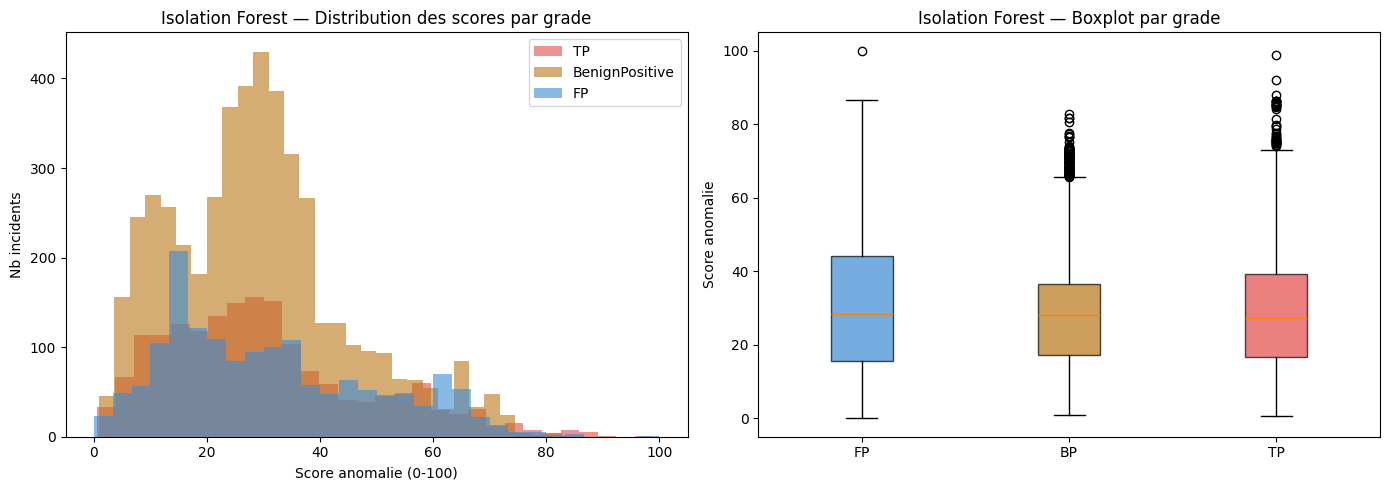

In [6]:
# Visualisation : distribution des scores Isolation Forest par grade
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grade_names = {2: 'TP', 1: 'BenignPositive', 0: 'FP'}
colors_grade = {2: '#E24B4A', 1: '#BA7517', 0: '#3B8BD4'}

for grade_code, grade_name in grade_names.items():
    mask = y_test == grade_code
    axes[0].hist(iso_score_test[mask], bins=30, alpha=0.6,
                 label=grade_name, color=colors_grade[grade_code])
axes[0].set_xlabel('Score anomalie (0-100)')
axes[0].set_ylabel('Nb incidents')
axes[0].set_title('Isolation Forest — Distribution des scores par grade')
axes[0].legend()

# Boxplot
data_box = [iso_score_test[y_test == g] for g in [0, 1, 2]]
bp = axes[1].boxplot(data_box, labels=['FP', 'BP', 'TP'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#3B8BD4', '#BA7517', '#E24B4A']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Score anomalie')
axes[1].set_title('Isolation Forest — Boxplot par grade')

plt.tight_layout()
plt.savefig(DATA_DIR / 'isolation_forest_scores.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# Évaluation non-supervisée : AUC TP vs reste
# (seule métrique applicable sans labels pendant l'entraînement)
auc_iso = roc_auc_score((y_test == 2).astype(int), iso_score_test)
print(f'AUC-ROC Isolation Forest (TP détection) : {auc_iso:.3f}')
print(f'  → Interprétation : un AUC > 0.60 montre que les incidents TP')
print(f'     ont tendance à avoir un score d\'anomalie plus élevé.')
print(f'  → Random = 0.50, Parfait = 1.00')

# Précision dans le top 20% des alertes
threshold_80 = np.percentile(iso_score_test, 80)
top20_mask = iso_score_test >= threshold_80
precision_top20 = (y_test[top20_mask] == 2).mean()
print(f'\nPrécision TP dans le top 20% alertes (score >= {threshold_80:.0f}) : {precision_top20:.1%}')
print(f'  vs {(y_test == 2).mean():.1%} dans l\'ensemble du dataset')

# Sauvegarde du modèle
joblib.dump({'model': iso_forest, 'scaler': scaler_iso}, MODEL_DIR / 'isolation_forest.pkl')
print(f'\nModèle sauvegardé : models/isolation_forest.pkl')

AUC-ROC Isolation Forest (TP détection) : 0.500
  → Interprétation : un AUC > 0.60 montre que les incidents TP
     ont tendance à avoir un score d'anomalie plus élevé.
  → Random = 0.50, Parfait = 1.00

Précision TP dans le top 20% alertes (score >= 42) : 23.9%
  vs 21.9% dans l'ensemble du dataset

Modèle sauvegardé : models/isolation_forest.pkl


## 3. Modèle 2 — XGBoost (supervisé)

**Principe** : utilise les labels IncidentGrade pour apprendre à distinguer TP/BP/FP. SMOTE compense le déséquilibre des classes. La calibration isotonique assure que les probabilités sont interprétables.

In [8]:
# Gestion du déséquilibre par SMOTE (sur train uniquement)
print('Application de SMOTE pour rééquilibrer les classes...')
print(f'Distribution avant SMOTE : {dict(pd.Series(y_train).value_counts())}')

smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Distribution après SMOTE : {dict(pd.Series(y_train_sm).value_counts())}')
print(f'Taille train augmentée : {len(X_train_sm):,}')

Application de SMOTE pour rééquilibrer les classes...
Distribution avant SMOTE : {1.0: 10048, 0.0: 6816, 2.0: 5028}
Distribution après SMOTE : {1.0: 10048, 2.0: 10048, 0.0: 10048}
Taille train augmentée : 30,144


In [9]:
# Entraînement XGBoost
print('Entraînement XGBoost...')

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0,
)

xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print('\nEntraînement terminé ✓')

Entraînement XGBoost...
[0]	validation_0-mlogloss:1.03934
[50]	validation_0-mlogloss:0.26040
[100]	validation_0-mlogloss:0.20178
[150]	validation_0-mlogloss:0.19211
[200]	validation_0-mlogloss:0.18809
[250]	validation_0-mlogloss:0.18606
[300]	validation_0-mlogloss:0.18533
[350]	validation_0-mlogloss:0.18533
[399]	validation_0-mlogloss:0.18503

Entraînement terminé ✓


In [10]:
# Prédictions
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)  # shape (n, 3) : [FP, BP, TP]

# Rapport de classification
grade_names_list = ['FP', 'BenignPositive', 'TP']
print('=== Rapport de classification XGBoost ===')
print(classification_report(y_test, y_pred, target_names=grade_names_list))

# F2-score (pénalise plus les faux négatifs TP)
f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')
print(f'F2-score (macro) : {f2:.3f}')
print('  → Le F2 est plus adapté au SOC : manquer un TP est 2x plus grave que de le sur-escalader')

=== Rapport de classification XGBoost ===
                precision    recall  f1-score   support

            FP       0.87      0.90      0.88      1583
BenignPositive       0.96      0.95      0.96      4753
            TP       0.88      0.88      0.88      1772

      accuracy                           0.92      8108
     macro avg       0.90      0.91      0.91      8108
  weighted avg       0.93      0.92      0.92      8108

F2-score (macro) : 0.907
  → Le F2 est plus adapté au SOC : manquer un TP est 2x plus grave que de le sur-escalader


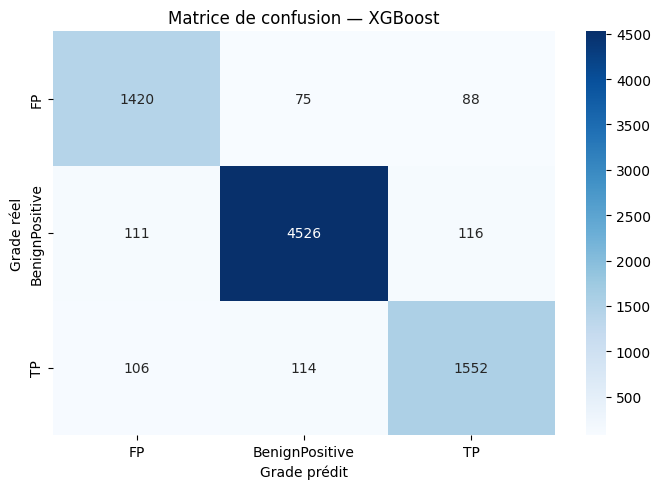

AUC-ROC XGBoost (macro OvR) : 0.989


In [11]:
# Matrice de confusion
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=grade_names_list, yticklabels=grade_names_list, ax=ax)
ax.set_title('Matrice de confusion — XGBoost')
ax.set_ylabel('Grade réel')
ax.set_xlabel('Grade prédit')
plt.tight_layout()
plt.savefig(DATA_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# AUC multi-classe
auc_xgb = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
print(f'AUC-ROC XGBoost (macro OvR) : {auc_xgb:.3f}')

## 4. Calcul du score de priorisation (0-100)

Le score présenté à l'analyste combine :
- La probabilité TP du modèle supervisé (principal)
- Le score d'anomalie Isolation Forest (secondaire, pour contexte)


In [12]:
# Score de priorisation : probabilité TP normalisée 0-100
proba_tp_test = y_proba[:, 2]  # colonne TP
priority_score = (proba_tp_test * 100).round(1)

# Définition des seuils (à ajuster selon la courbe PR)
# Ces seuils sont déterminés sur la courbe Precision-Recall
SEUIL_ACTION_URGENTE = 75
SEUIL_ESCALADE_N2 = 45
SEUIL_INVESTIGATION = 20
# < 20 → FP probable → clôture suggérée

def get_decision(score):
    if score >= SEUIL_ACTION_URGENTE:
        return 'ACTION_URGENTE'
    elif score >= SEUIL_ESCALADE_N2:
        return 'ESCALADE_N2'
    elif score >= SEUIL_INVESTIGATION:
        return 'INVESTIGATION_N1'
    else:
        return 'CLOTURE_FP'

decisions_test = np.array([get_decision(s) for s in priority_score])

print('Distribution des décisions suggérées :')
decision_counts = pd.Series(decisions_test).value_counts()
for dec, cnt in decision_counts.items():
    print(f'  {dec}: {cnt:,} ({cnt/len(decisions_test):.1%})')

# Validation des seuils
print('\nValidation des seuils (test set) :')
for decision in ['ACTION_URGENTE', 'ESCALADE_N2', 'INVESTIGATION_N1', 'CLOTURE_FP']:
    mask = decisions_test == decision
    if mask.sum() > 0:
        tp_rate = (y_test[mask] == 2).mean()
        fp_rate = (y_test[mask] == 0).mean()
        print(f'  {decision}: {mask.sum():,} incidents | TP={tp_rate:.1%} | FP={fp_rate:.1%}')

Distribution des décisions suggérées :
  CLOTURE_FP: 5,978 (73.7%)
  ACTION_URGENTE: 1,447 (17.8%)
  INVESTIGATION_N1: 417 (5.1%)
  ESCALADE_N2: 266 (3.3%)

Validation des seuils (test set) :
  ACTION_URGENTE: 1,447 incidents | TP=96.7% | FP=1.2%
  ESCALADE_N2: 266 incidents | TP=47.7% | FP=23.3%
  INVESTIGATION_N1: 417 incidents | TP=35.7% | FP=26.1%
  CLOTURE_FP: 5,978 incidents | TP=1.6% | FP=23.3%


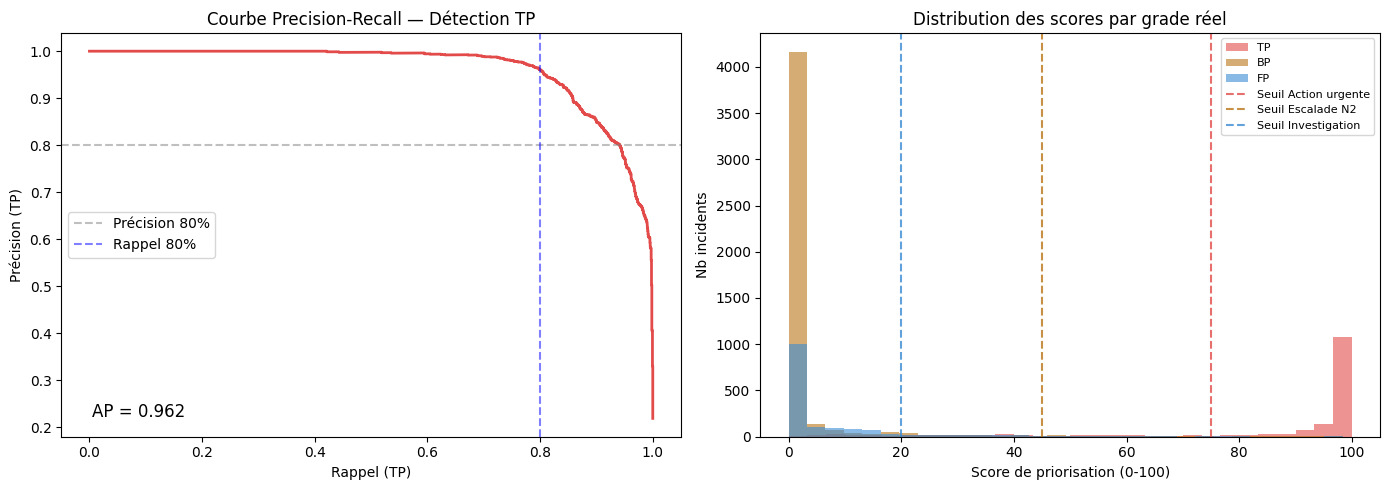

In [13]:
# Courbe Precision-Recall pour ajuster les seuils
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve pour TP
precision, recall, thresholds = precision_recall_curve((y_test == 2).astype(int), proba_tp_test)
axes[0].plot(recall, precision, color='#E24B4A', lw=2)
axes[0].axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='Précision 80%')
axes[0].axvline(0.8, color='blue', linestyle='--', alpha=0.5, label='Rappel 80%')
axes[0].set_xlabel('Rappel (TP)')
axes[0].set_ylabel('Précision (TP)')
axes[0].set_title('Courbe Precision-Recall — Détection TP')
axes[0].legend()

ap = average_precision_score((y_test == 2).astype(int), proba_tp_test)
axes[0].text(0.05, 0.05, f'AP = {ap:.3f}', transform=axes[0].transAxes, fontsize=12)

# Distribution des scores par grade
for grade_code, grade_name, color in [(2,'TP','#E24B4A'), (1,'BP','#BA7517'), (0,'FP','#3B8BD4')]:
    mask = y_test == grade_code
    axes[1].hist(priority_score[mask], bins=30, alpha=0.6, label=grade_name, color=color)

# Lignes de seuils
for seuil, label, color in [
    (SEUIL_ACTION_URGENTE, 'Action urgente', '#E24B4A'),
    (SEUIL_ESCALADE_N2, 'Escalade N2', '#BA7517'),
    (SEUIL_INVESTIGATION, 'Investigation', '#3B8BD4')
]:
    axes[1].axvline(seuil, color=color, linestyle='--', alpha=0.8, label=f'Seuil {label}')

axes[1].set_xlabel('Score de priorisation (0-100)')
axes[1].set_ylabel('Nb incidents')
axes[1].set_title('Distribution des scores par grade réel')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / 'priority_scores.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Feature Importance globale

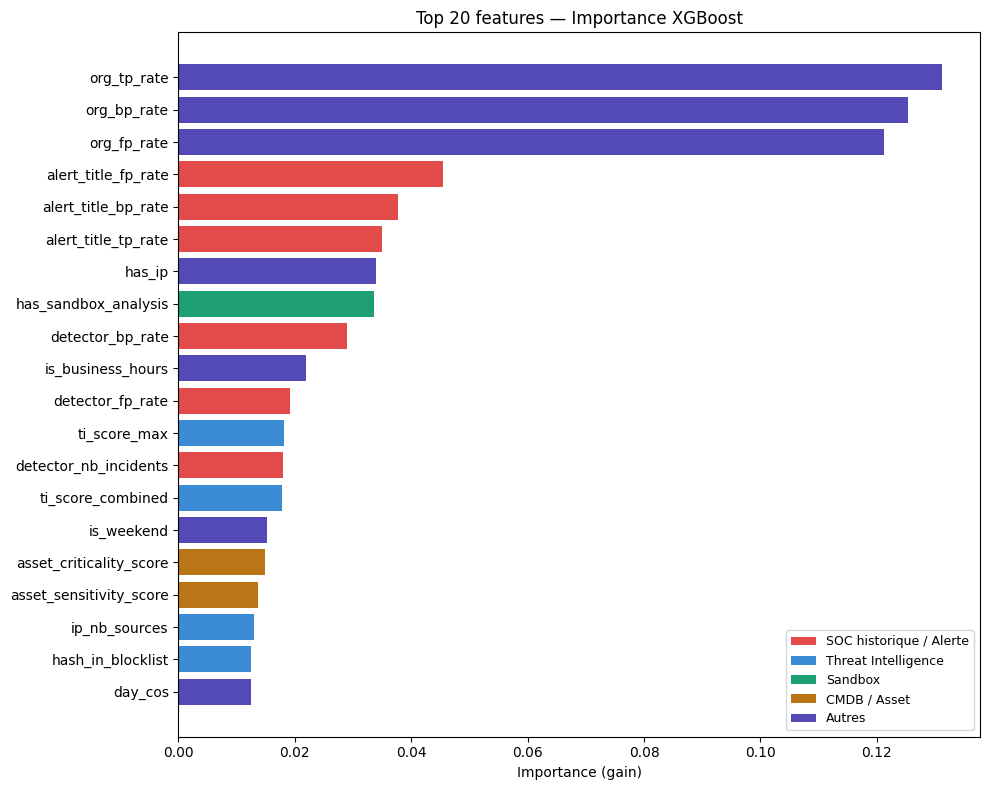

Top 10 features importantes :
org_tp_rate             0.1312
org_bp_rate             0.1253
org_fp_rate             0.1213
alert_title_fp_rate     0.0455
alert_title_bp_rate     0.0377
alert_title_tp_rate     0.0350
has_ip                  0.0340
has_sandbox_analysis    0.0336
detector_bp_rate        0.0289
is_business_hours       0.0219
dtype: float32


In [14]:
importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
top_imp = importances.head(top_n)
colors_imp = ['#E24B4A' if 'detector' in c or 'alert_title' in c
               else '#3B8BD4' if 'ti_' in c or 'hash' in c or 'ip_' in c
               else '#1D9E75' if 'sandbox' in c
               else '#BA7517' if 'asset' in c
               else '#534AB7'
               for c in top_imp.index]
bars = ax.barh(range(top_n), top_imp.values, color=colors_imp)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_imp.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Importance (gain)')
ax.set_title('Top 20 features — Importance XGBoost')

# Légende manuelle
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E24B4A', label='SOC historique / Alerte'),
    Patch(facecolor='#3B8BD4', label='Threat Intelligence'),
    Patch(facecolor='#1D9E75', label='Sandbox'),
    Patch(facecolor='#BA7517', label='CMDB / Asset'),
    Patch(facecolor='#534AB7', label='Autres'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR / 'feature_importance_xgb.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 features importantes :')
print(importances.head(10).round(4))

## 6. Simulation du feedback loop (théorique)

**Concept** : après validation par l'analyste, les décisions corrigées enrichissent le dataset d'entraînement. On simule ici l'amélioration attendue sur 3 cycles.

=== Simulation du Feedback Loop ===

Principe : l'analyste valide ou corrige la décision suggérée.
Ces corrections deviennent de nouveaux labels pour réentraîner le modèle.

Cycle 1 (2,189 feedbacks) → F2-score : 0.918
Cycle 2 (5,473 feedbacks) → F2-score : 0.924
Cycle 3 (10,946 feedbacks) → F2-score : 0.923


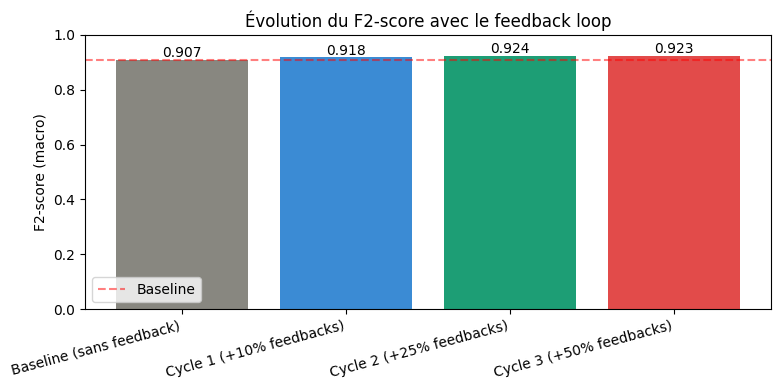

In [15]:
print('=== Simulation du Feedback Loop ===\n')
print('Principe : l\'analyste valide ou corrige la décision suggérée.')
print('Ces corrections deviennent de nouveaux labels pour réentraîner le modèle.\n')

# Simulation : on prend un sous-ensemble du test comme "feedbacks validés"
# et on montre l'amélioration du F2-score

results_feedback = []
f2_baseline = fbeta_score(y_test, y_pred, beta=2, average='macro')
results_feedback.append({'cycle': 0, 'type': 'Baseline (sans feedback)',
                          'n_feedback': 0, 'f2_score': f2_baseline})

for cycle, feedback_pct in enumerate([0.1, 0.25, 0.5], 1):
    n_feedback = int(len(X_train) * feedback_pct)
    # Simuler l'ajout de n_feedback nouveaux exemples labellisés
    np.random.seed(RANDOM_SEED + cycle)
    feedback_idx = np.random.choice(len(X_test),
                                     size=min(n_feedback, len(X_test)//2),
                                     replace=False)

    X_train_aug = np.vstack([X_train_sm, X_test[feedback_idx]])
    y_train_aug = np.concatenate([y_train_sm, y_test[feedback_idx]])

    # Réentraînement rapide
    xgb_aug = xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        objective='multi:softprob', num_class=3,
        random_state=RANDOM_SEED, n_jobs=-1, verbosity=0
    )
    xgb_aug.fit(X_train_aug, y_train_aug)
    y_pred_aug = xgb_aug.predict(X_test)
    f2_aug = fbeta_score(y_test, y_pred_aug, beta=2, average='macro')

    results_feedback.append({
        'cycle': cycle,
        'type': f'Cycle {cycle} (+{feedback_pct:.0%} feedbacks)',
        'n_feedback': n_feedback,
        'f2_score': f2_aug
    })
    print(f'Cycle {cycle} ({n_feedback:,} feedbacks) → F2-score : {f2_aug:.3f}')

results_df = pd.DataFrame(results_feedback)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(results_df['type'], results_df['f2_score'],
       color=['#888780', '#3B8BD4', '#1D9E75', '#E24B4A'])
ax.set_ylim(0, 1)
ax.set_ylabel('F2-score (macro)')
ax.set_title('Évolution du F2-score avec le feedback loop')
ax.axhline(f2_baseline, color='red', linestyle='--', alpha=0.5, label='Baseline')
ax.legend()
plt.xticks(rotation=15, ha='right')
for i, (_, row) in enumerate(results_df.iterrows()):
    ax.text(i, row['f2_score'] + 0.01, f'{row["f2_score"]:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(DATA_DIR / 'feedback_loop_simulation.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Génération du fichier de prédictions pour la démo Streamlit

In [16]:
DEMO_SIZE = 500

# Charger incidents_dataset pour récupérer les colonnes d'affichage démo
incidents_ds = pd.read_csv(DATA_DIR / 'incidents_dataset.csv',
                            dtype={'sample_device_id': str})

test_df = df.iloc[test_idx].reset_index(drop=True)
predictions_df = test_df[['IncidentId', 'OrgId']].copy()

# Enrichissement depuis incidents_dataset (colonnes d'affichage pour la démo)
predictions_df = predictions_df.merge(
    incidents_ds[['IncidentId', 'top_alert_title', 'top_category', 'first_seen',
                  'nb_alerts', 'sample_ip', 'sample_device_id', 'sample_device',
                  'sample_account', 'sample_sha256', 'IncidentGrade']],
    on='IncidentId', how='left'
)

# Scores et décisions
predictions_df['priority_score']    = priority_score
predictions_df['iso_anomaly_score'] = iso_score_test.round(1)
predictions_df['proba_fp']          = (y_proba[:, 0] * 100).round(1)
predictions_df['proba_bp']          = (y_proba[:, 1] * 100).round(1)
predictions_df['proba_tp']          = (y_proba[:, 2] * 100).round(1)
predictions_df['decision_suggested'] = decisions_test
predictions_df['grade_reel']         = y_test
predictions_df['grade_reel_label']   = predictions_df['grade_reel'].map(
    {2: 'TruePositive', 1: 'BenignPositive', 0: 'FalsePositive'})
predictions_df['prediction_label']   = pd.Series(y_pred).map(
    {2: 'TruePositive', 1: 'BenignPositive', 0: 'FalsePositive'}).values

def get_severity(score):
    if score >= 75:   return 'CRITIQUE'
    elif score >= 45: return 'HAUTE'
    elif score >= 20: return 'MOYENNE'
    else:             return 'FAIBLE'

predictions_df['severity'] = predictions_df['priority_score'].apply(get_severity)

# Échantillon stratifié pour la démo
demo_sample = predictions_df.groupby('decision_suggested', group_keys=False).apply(
    lambda g: g.sample(min(len(g), int(DEMO_SIZE * len(g) / len(predictions_df)) + 5),
                       random_state=RANDOM_SEED)
).sample(DEMO_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)

demo_sample = demo_sample.sort_values('priority_score', ascending=False).reset_index(drop=True)

# Sauvegardes
demo_sample.to_csv(DATA_DIR / 'predictions_sample.csv', index=False)
predictions_df.to_csv(DATA_DIR / 'predictions_full.csv', index=False)
joblib.dump(xgb_model, MODEL_DIR / 'xgboost_model.pkl')

# Sauvegarder aussi la fonction d'encodage et la liste des features pour l'inférence
inference_config = {
    'feature_cols':   FEATURE_COLS,
    'global_rates':   global_rates,
    'grade_map':      {0: 'FalsePositive', 1: 'BenignPositive', 2: 'TruePositive'},
    'seuils': {
        'ACTION_URGENTE':   SEUIL_ACTION_URGENTE,
        'ESCALADE_N2':      SEUIL_ESCALADE_N2,
        'INVESTIGATION_N1': SEUIL_INVESTIGATION,
    }
}
with open(MODEL_DIR / 'inference_config.pkl', 'wb') as f:
    pickle.dump(inference_config, f)

print(f'✅ predictions_sample.csv  : {len(demo_sample):,} incidents pour la démo')
print(f'✅ predictions_full.csv    : {len(predictions_df):,} incidents (test set complet)')
print(f'✅ xgboost_model.pkl       : modèle XGBoost')
print(f'✅ inference_config.pkl    : config complète pour l\'inférence SIEM')
print(f'\nDistribution dans la démo :')
print(demo_sample['decision_suggested'].value_counts())
print('\n→ Prochaine étape : 04_xai.ipynb')

✅ predictions_sample.csv  : 500 incidents pour la démo
✅ predictions_full.csv    : 8,108 incidents (test set complet)
✅ xgboost_model.pkl       : modèle XGBoost
✅ inference_config.pkl    : config complète pour l'inférence SIEM

Distribution dans la démo :
decision_suggested
CLOTURE_FP          359
ACTION_URGENTE       91
INVESTIGATION_N1     29
ESCALADE_N2          21
Name: count, dtype: int64

→ Prochaine étape : 04_xai.ipynb


/var/folders/fb/n81c_xk9361bflkbqt783n_00000gn/T/ipykernel_10040/1811186707.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  demo_sample = predictions_df.groupby('decision_suggested', group_keys=False).apply(
